In [2]:
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [8]:

true_slope = 5
true_intercept = 10
true_sigma = 1

num_points = 10

x_vals = np.linspace(0, 1, num_points)
true_y_vals = true_slope * x_vals + true_intercept
y_vals = true_y_vals + np.random.normal(scale=true_sigma, size=num_points)

true_params = {'slope': true_slope, 'intercept': true_intercept, 'sigma': true_sigma}

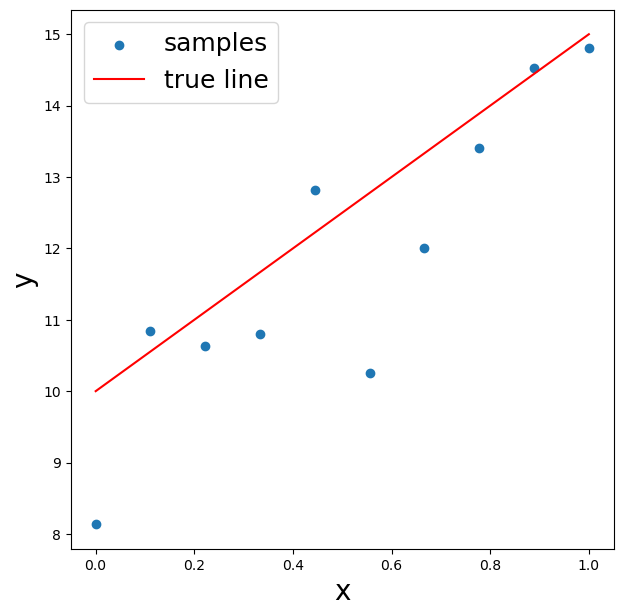

In [9]:
plt.figure(figsize=(7,7))
p1 = plt.scatter(x_vals, y_vals)
p2, = plt.plot(x_vals, true_y_vals, color='r')
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.legend((p1, p2), ('samples', 'true line'), fontsize=18)

In [10]:
clf = LinearRegression()
clf.fit(x_vals.reshape(-1,1), y_vals)
preds = clf.predict(x_vals.reshape(-1,1))
resids = preds - y_vals

print('True Model:')
print('y_true = %s*x + %s'%(true_slope, true_intercept))
print('True sigma: %s\n'%true_params['sigma'])

print('Estimated Model:')
print('y_hat = %s*x + %s'%(clf.coef_[0], clf.intercept_))
print('Sd Residuals: %s'%(resids.std()))

mle_estimates = {'slope': clf.coef_[0], 'intercept': clf.intercept_, 'sigma': resids.std()}

True Model:
y_true = 5*x + 10
True sigma: 1

Estimated Model:
y_hat = 5.496743827115258*x + 9.074172804447986
Sd Residuals: 0.9205103146280106


In [11]:
with pm.Model() as model:
    #priors
    sigma = pm.Exponential("sigma", lam=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=20)
    slope = pm.Normal("slope", mu=0, sigma=20)

    #Likelihood
    likelihood = pm.Normal("y", mu=slope*x_vals + intercept, sigma=sigma, observed=y_vals)

    #posterior
    trace = pm.sample(1000, cores=4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, slope]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 89 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


<Figure size 700x700 with 0 Axes>

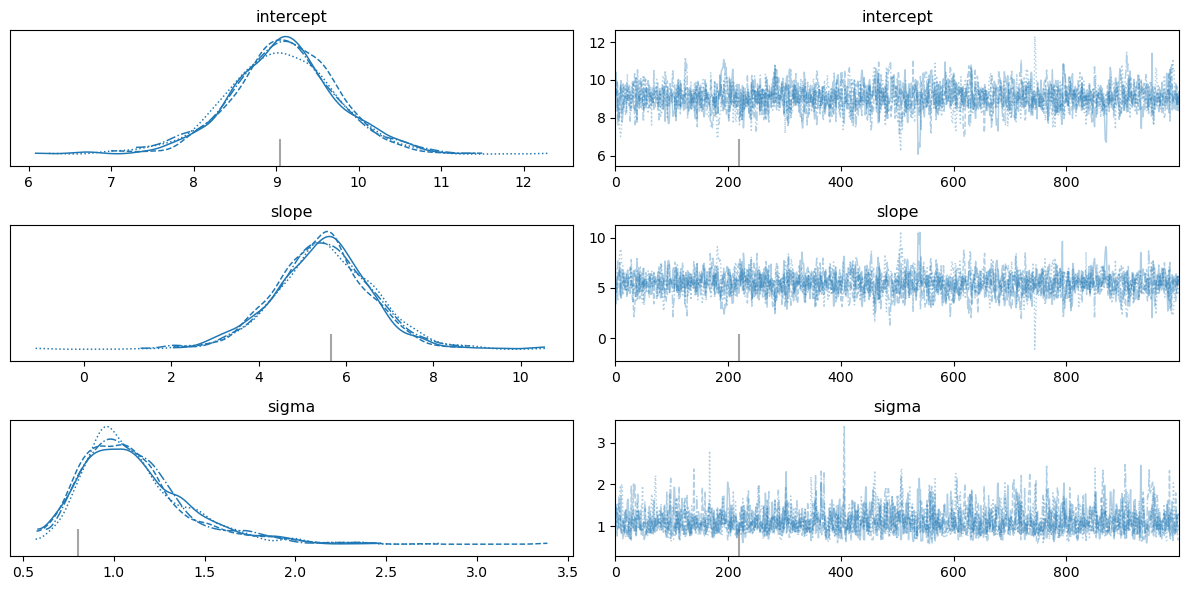

In [12]:
plt.figure(figsize=(7, 7))
pm.plot_trace(trace)
plt.tight_layout()

In [13]:
for var in ['slope', 'intercept', 'sigma']:
    plt.figure(figsize=(10,4))
    vals = trace.get_values(var)
    mean, lower, upper = round(vals.mean(),2), round(vals.mean()-vals.std(),2), round(vals.mean()+vals.std(),2)
    sns.distplot(vals)
    posterior_est = plt.axvline(mean, color='b')
    mle_est = plt.axvline(mle_estimates[var], color='b', linestyle='dotted')
    plt.axvline(lower, color='r', linestyle='--')
    plt.axvline(upper, color='r', linestyle='--')
    plt.title('%s [True = %s]\nPosterior Mean: %s\nBound: (%s, %s)'%(var,true_params[var],mean,lower,upper), fontsize=20)
    true_val = plt.axvline(true_params[var], color='k')

    plt.legend((true_val, mle_est, posterior_est), ('true', 'MLE', 'Posterior Mean'), fontsize=18)

    plt.show()

AttributeError: 'InferenceData' object has no attribute 'get_values'

<Figure size 1000x400 with 0 Axes>

In [4]:
players_preds = pd.read_csv('./../FPL predictors/with new features/predicted.csv')
# print(players_preds)
players_preds = players_preds.dropna(axis=1).copy()
players_preds = players_preds.drop(['event', 'understat_id', 'xg_pred', 'xa_pred', 'cs_pred', 'yc_pred', 'sv_pred', 'h_team', 'a_team','was_home'], axis=1)
player_cols = players_preds.columns.tolist()

gk_preds = players_preds[players_preds['position'] == 'GK'][player_cols]
def_preds = players_preds[players_preds['position'] == 'DEF'][player_cols]
mid_preds = players_preds[players_preds['position'] == 'MID'][player_cols]
fwd_preds = players_preds[players_preds['position'] == 'FWD'][player_cols]


gk_preds = gk_preds.drop(['position'], axis=1)
def_preds = def_preds.drop(['position'], axis=1)
mid_preds = mid_preds.drop(['position'], axis=1)
fwd_preds = fwd_preds.drop(['position'], axis=1)
# gk_data = gk_data.to_numpy(dtype=np.float64)

In [5]:
gw = 28
data_22_23 = pd.read_csv('../FPL predictors/with new features/data/joint/22-23/merged_player_data.csv').dropna()
data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('../FPL predictors/with new features/data/joint/24-25/merged_player_data.csv')
data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] != gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_cols = player_cols.copy()
data_cols.pop(data_cols.index('xPts'))
data_cols.pop(data_cols.index('fpl_id'))

'fpl_id'

In [6]:
from sklearn.preprocessing import minmax_scale
# scaler = StandardScaler()
data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
                        'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
                        'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5'], axis=1)
gk_data_scaled = minmax_scale(gk_data)
gk_data = pd.DataFrame(gk_data_scaled)


def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
                        'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
                        'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5'], axis=1)
def_data_scaled = minmax_scale(def_data)
def_data = pd.DataFrame(def_data_scaled)

mid_data = mid_data.drop(['position'], axis=1)
# mid_data = pd.get_dummies(mid_data, columns=['was_home'], dtype=float)
mid_data_scaled = minmax_scale(mid_data)
mid_data = pd.DataFrame(gk_data_scaled)

fwd_data = fwd_data.drop(['position'], axis=1)
# fwd_data = pd.get_dummies(fwd_data, columns=['was_home'], dtype=float)
fwd_data_scaled = minmax_scale(fwd_data)
fwd_data = pd.DataFrame(gk_data_scaled)

# gk_data = gk_data.to_numpy(dtype=np.float64)



ValueError: could not convert string to float: 'Everton'

In [6]:
import pymc as pm
import numpy as np
import pandas as pd

In [51]:
beta = [-0.00134603, -0.00872736, -0.09936062,  0.214492,   0.25493401,  0.18379091, 0.0076735,   0.0138302,  -0.41148549,  0.63609721,  0.18111913, -0.00842038,
        0.09850101,  0.06817671,  0.23008687,  0.01546236, -0.12580747, -0.29967013, -0.19296348, -0.36609276, -0.24658675, -0.10396605, -0.36175011,  0.4385429,
        -0.62631235,  0.06730157,  0.08897252,  0.40705204, -0.67796046, -0.43882293, -0.00862078,  0.03643274, -0.3468878,  -0.02760149, -0.51804128,  0.32833594,
        0.29893174,  0.03985856,  0.34326533,  0.25154841,  0.27442046,  0.37671672, 0.2046367,   0.21339364,]

X = fwd_data
# Step 1: Compute alpha values
alpha = np.exp(np.dot(X, beta))

f = len(beta)  # Number of groups
# alpha
# Step 2: Define and sample from Dirichlet distribution
with pm.Model() as model:
    q = 0.5 # pm.Beta("q", alpha=2, beta=5)  # Prior: More likely to select independently
    p = pm.Dirichlet("p", a=alpha, shape=(f, X.shape[1]))  # Ensure correct shape
    trace = pm.sample_prior_predictive(samples=1)

# Extract samples correctly
sampled_p = trace.prior["p"].values.squeeze()  # Ensure shape is (f, num_features)

W = set()  # Placeholder for valid portfolios
Wo = []  # List to store accepted portfolios

# Step 3-17: Sampling loop
for _ in range(2074065):
        Stack = np.random.binomial(1, q)  # Sample Bernoulli(q)
        print(Stack)
        Reject = True

        while Reject:
            # Step 7: Sample from Multinomial(1, p)
            k = [np.random.multinomial(1, sampled_p[i, :]).argmax() for i in range(15)]
            print(k)


            if Stack == 1:
                # Step 9: Replace first selection with main team member
                k[0] = np.random.choice(k)  # Adjust as needed for "main m"

            wo = tuple(k)  # Portfolio representation

            # Step 12: Acceptance condition
            if wo in W and c * sum(wo) >= Blb:
                Reject = False
                Wo.append(wo)
        print(Wo)

Wo

ValueError: shapes (3789,74) and (44,) not aligned: 74 (dim 1) != 44 (dim 0)

In [41]:
# Get estimated β values

trace.prior['p'].values.squeeze()

array([[1.22048693e-03, 1.61224805e-03, 2.40560844e-04, ...,
        6.06640359e-04, 2.52599313e-04, 2.35736270e-04],
       [7.90126658e-04, 5.39708555e-04, 6.19785019e-04, ...,
        7.64904182e-05, 2.65986399e-04, 1.73347331e-03],
       [3.33797644e-05, 9.12854517e-04, 1.42742597e-03, ...,
        9.61464207e-04, 2.97059709e-04, 5.03675545e-04],
       ...,
       [1.17115252e-03, 1.14265225e-05, 3.94502606e-04, ...,
        1.54470240e-04, 6.65570575e-05, 5.86349773e-04],
       [1.54431666e-03, 7.20652266e-04, 8.58378129e-04, ...,
        7.42959336e-04, 5.56410243e-04, 4.08669241e-04],
       [4.76444863e-04, 1.10595377e-04, 4.12616174e-04, ...,
        5.63790995e-04, 7.97447367e-04, 2.56272127e-04]])

In [42]:
import numpy as np

def sample_lineups(num_lineups, num_positions, p, q):
    """
    Implements Algorithm 2: Mixture of Stacking and Independence Copulas.

    Args:
        num_lineups (int): Number of lineups to generate.
        num_positions (int): Number of player positions (e.g., 11 for a full lineup).
        p (np.array): Probability vector for selecting each player.
        q (float): Probability of allowing stacking.

    Returns:
        list: List of generated lineups.
    """

    lineups = []

    for _ in range(num_lineups):
        Stack = np.random.binomial(1, q)  # Bernoulli(q) to decide stacking
        lineup = []

        if Stack == 1:
            # Stacking: Sample some players from the same team
            main_team = np.random.choice(len(p), 1, p=p)  # Choose a team to stack
            for _ in range(num_positions):
                player = np.random.choice(len(p), 1, p=p)  # Select player
                lineup.append(player[0])

        else:
            # Independent selection: Each position sampled separately
            lineup = np.random.choice(len(p), num_positions, p=p, replace=False)

        lineups.append(lineup)

    return lineups

# Example Usage
num_lineups = 5
num_positions = 11
p = np.ones(20) / 20  # Example: Uniform probability over 20 players
q = 0.3  # 30% chance of stacking

generated_lineups = sample_lineups(num_lineups, num_positions, p, q)
for i, lineup in enumerate(generated_lineups):
    print(f"Lineup {i+1}: {lineup}")


Lineup 1: [10 17  2 19  6  1 16  7 13  0  4]
Lineup 2: [ 9 17 11 13  1  8  5 15 10  4 16]
Lineup 3: [ 2  7 13  1 18 17  9 14 19  0  6]
Lineup 4: [3, 0, 15, 18, 1, 5, 5, 9, 15, 1, 9]
Lineup 5: [8, 18, 9, 3, 15, 19, 16, 12, 10, 6, 12]


In [43]:
import pymc as pm
import numpy as np
import arviz as az

def generate_beta(num_players):
    """
    Step 1: Bayesian estimation of player skill coefficients (beta_g).

    Args:
        num_players (int): Total number of players.

    Returns:
        np.array: Estimated beta values.
    """
    with pm.Model() as model:
        # Normal prior for player skill coefficients
        beta_g = pm.Normal("beta_g", mu=0, sigma=1, shape=(num_players,))

        # MCMC sampling
        trace = pm.sample(2000, return_inferencedata=True, target_accept=0.9)

    # Extract estimated beta values
    beta_estimated = trace.posterior["beta_g"].mean(dim=["chain", "draw"]).values
    return beta_estimated

# Example Usage
num_players = 20
beta_values = generate_beta(num_players)
print("Estimated Beta Values:\n", beta_values)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta_g]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 285 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Estimated Beta Values:
 [-0.03858768  0.00590701 -0.01717171 -0.00065615  0.0058231   0.00438732
 -0.00594865  0.00091248  0.0150004  -0.00466347 -0.02093122 -0.00946461
 -0.00388743  0.01028761 -0.01260872  0.00916809 -0.00199343 -0.00433557
  0.00862072  0.00465678]


## For now


In [7]:
from sklearn.preprocessing import minmax_scale
# scaler = StandardScaler()
data_ = data_tar[data_cols]
gk_data_tar = data_tar[data_tar['position'] == '1'][data_cols]
def_data_tar = data_tar[data_tar['position'] == '2'][data_cols]
mid_data_tar = data_tar[data_tar['position'] == '3'][data_cols]
fwd_data_tar = data_tar[data_tar['position'] == '4'][data_cols]


gk_data_tar = gk_data_tar.select_dtypes(include=[np.number])
gk_data_tar = gk_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
                        'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
                        'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5'], axis=1)
gk_data_tar = pd.DataFrame(minmax_scale(gk_data_tar), columns=gk_data_tar.columns, index=gk_data_tar.index)

def_data_tar = def_data_tar.select_dtypes(include=[np.number])
def_data_tar = def_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
                        'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
                        'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5','whh','whd', 'wha'], axis=1)
def_data_tar = pd.DataFrame(minmax_scale(def_data_tar), columns=def_data_tar.columns, index=def_data_tar.index)

mid_data_tar = mid_data_tar.select_dtypes(include=[np.number])
mid_data_tar = mid_data_tar.drop(['expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_3', 'goals_scored_3', 'own_goals_3', 'goals_3', 'shots_3', 'xG_3',
                        'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3', 'xA_3', 'assists_y_3', 'expected_goals_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_5', 'goals_scored_5', 'own_goals_5', 'goals_5', 'shots_5', 'xG_5',
                        'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5', 'xA_5', 'assists_y_5','whh','whd', 'wha'], axis=1)
mid_data_tar = pd.DataFrame(minmax_scale(mid_data_tar), columns=mid_data_tar.columns, index=mid_data_tar.index)

fwd_data_tar = fwd_data_tar.select_dtypes(include=[np.number])
fwd_data_tar = pd.DataFrame(minmax_scale(fwd_data_tar), columns=fwd_data_tar.columns, index=fwd_data_tar.index)

In [8]:
beta_gk_ = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def_ = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid_ = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd_ = pd.read_csv('./fwd_beta.csv').values.squeeze()

alpha_gk_pred = np.exp(np.dot(gk_data_tar, beta_gk_.T))
alpha_def_pred = np.exp(np.dot(def_data_tar, beta_def_.T))
alpha_mid_pred = np.exp(np.dot(mid_data_tar, beta_mid_.T))
alpha_fwd_pred = np.exp(np.dot(fwd_data_tar, beta_fwd_.T))

In [9]:

f = len(beta_gk_)  # Number of groups

# Step 2: Define and sample from Dirichlet distribution
with pm.Model() as model:
    p_gk = pm.Dirichlet("p_gk", a=alpha_gk_pred)  # Ensure correct shape
    p_def = pm.Dirichlet("p_def", a=alpha_def_pred)  # Ensure correct shape
    p_mid = pm.Dirichlet("p_mid", a=alpha_mid_pred)  # Ensure correct shape
    p_fwd = pm.Dirichlet("p_fwd", a=alpha_fwd_pred)  # Ensure correct shape

    trace = pm.sample_prior_predictive(samples=1)

Sampling: [p_def, p_fwd, p_gk, p_mid]


In [10]:
# Extract samples correctly
pg = trace.prior["p_gk"].values.squeeze()  # Ensure shape is (f, num_features)
pdef = trace.prior["p_def"].values.squeeze()  # Ensure shape is (f, num_features)
pmid = trace.prior["p_mid"].values.squeeze()  # Ensure shape is (f, num_features)
pf = trace.prior["p_fwd"].values.squeeze()  # Ensure shape is (f, num_features)


In [37]:
import requests
# Define the API endpoint
url = 'https://fantasy.premierleague.com/api/bootstrap-static/'

# Send a GET request to the API
response = requests.get(url)
player_data = None
# Check if the request was successful
if response.status_code == 200:
    data = response.json()  # Parse the JSON data
    players = data['elements']  # Extract the list of players

    player_data = [
        {"id": player["id"],  "name": f"{player['first_name']} {player['second_name']}", "player_team": player["team"], "price": player["now_cost"] / 10, "position": player["element_type"]}
        for player in players
    ]

else:
    print('Failed to retrieve data')

fpl_players = pd.DataFrame(player_data)

In [14]:
g_prices = data_tar[data_tar['position'] == '1'][['value']]*10
d_prices = data_tar[data_tar['position'] == '2'][['value']]*10
m_prices = data_tar[data_tar['position'] == '3'][['value']]*10
f_prices = data_tar[data_tar['position'] == '4'][['value']]*10

In [ ]:
# === Step 1: Define Constants ===
P = 100  # Total available players
C = 15  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget
O = 1000  # Number of squad simulations


# === Step 3: Generate Possible Team Selections (Algorithm 1) ===
def generate_squad(pg, pd, pmid, pf, q, budget):
    """Generate a valid team selection for an opponent."""
    stack = np.random.binomial(1, q)  # Stacking decision

    selected_g = np.random.multinomial(2, pg)
    sel_g_ = [idx for idx, _ in enumerate(selected_g)]
    print(sel_g_)
    selected_d = np.random.multinomial(5, pd)
    selected_m = np.random.multinomial(5, pmid)
    selected_f = np.random.multinomial(3, pf)

    # Apply stacking (if enabled, pick an extra midfielder from the same club as a forward)
    if stack:
        selected_m[0] = selected_f[0]  # Stack a midfielder with a forward

    g_cost = np.dot(selected_g, g_prices)[0]
    d_cost = np.dot(selected_d, d_prices)[0]
    m_cost = np.dot(selected_m, m_prices)[0]
    f_cost = np.dot(selected_f, f_prices)[0]



    # Ensure total budget is within limits
    player_costs = np.random.uniform(4, 12, P)  # Simulated player costs
    squad = np.concatenate([selected_g, selected_d, selected_m, selected_f])

    # Check  if no players no more than 3 players from the same team are selected
    print(data_tar['player_team'])
    total_cost = sum([g_cost, d_cost, m_cost, f_cost])



    if (total_cost > budget) and (total_cost < Blb):
        return None  # Reject and retry

    return squad

# Generate O possible squads
O = 500
q = 0.25  # Assume 30% stacking probability
Wo = []
while len(Wo) < O:

    squad = generate_squad(pg, pdef, pmid, pf, q, budget)
    # print('*****: ', squad)
    if squad is not None:
        # print('============>', squad)
        Wo.append(squad.tolist())

# Print example squad
print("Example Generated Squad:", Wo[0])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
12      9
19      4
44      4
53      4
74      4
       ..
8762    4
8765    4
8772    4
8801    4
8830    4
Name: player_team, Length: 517, dtype: object
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
12      9
19      4
44      4
53      4
74      4
       ..
8762    4
8765    4
8772    4
8801    4
8830    4
Name: player_team, Length: 517, dtype: object
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]
12      9
19      4
44      4
53      4
74      4
       ..
8762    4
8765    4
8772    4
8801    4
8830    4
Name: player_team, Length: 517, dtype: object
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 

In [63]:
np.multiply([1,23,4], [3,4,5])

array([ 3, 92, 20])